<img src="../Pierian-Data-Logo.PNG">
<br>
<strong><center>Copyright 2019. Created by Jose Marcial Portilla.</center></strong>

# CNN on Custom Images
For this exercise we're using a collection of Cats and Dogs images inspired by the classic <a href='https://www.kaggle.com/c/dogs-vs-cats'>Kaggle competition</a>.

In the last section we downloaded the files, looked at the directory structure, examined the images, and performed a variety of transforms in preparation for training.

In this section we'll define our model, then feed images through a training and validation sequence using DataLoader.



### Image files directory tree
<pre>.
└── Data
    └── CATS_DOGS
        ├── test
        │   ├── CAT
        │   │   ├── 9374.jpg
        │   │   ├── 9375.jpg
        │   │   └── ... (3,126 files)
        │   └── DOG
        │       ├── 9374.jpg
        │       ├── 9375.jpg
        │       └── ... (3,125 files)       
        │           
        └── train
            ├── CAT
            │   ├── 0.jpg
            │   ├── 1.jpg
            │   └── ... (9,371 files)
            └── DOG
                ├── 0.jpg
                ├── 1.jpg
                └── ... (9,372 files)</pre>

In [1]:
!nvidia-smi

Tue Jun 16 03:26:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Perform standard imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
from torch.utils.data import DataLoader
from torchvision import datasets , transforms , models
from torchvision.utils import make_grid

In [5]:
import pandas as pd
import numpy as np

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackened.format_figure = "svg"

In [7]:
import os

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
# Mount Drive and use the dataset directly
from google.colab import drive
drive.mount('/content/drive')

# Path to your saved dataset``
dataset_root = '/content/drive/MyDrive/colab_datasets/cats_dogs_dataset/CATS_DOGS'

# Access training images
train_path = os.path.join(dataset_root, 'train')
test_path = os.path.join(dataset_root, 'test')

# Check what's inside train folder
print("Contents of CATS_DOGS:", os.listdir(dataset_root))
print("Train folder contents:", os.listdir(train_path)[:10])
print("Test folder contents:", os.listdir(test_path)[:10])

Mounted at /content/drive
Contents of CATS_DOGS: ['test', 'train']
Train folder contents: ['CAT', 'DOG']
Test folder contents: ['CAT', 'DOG']


## Define transforms
In the previous section we looked at a variety of transforms available for data augmentation (rotate, flip, etc.) and normalization.<br>
Here we'll combine the ones we want, including the <a href='https://discuss.pytorch.org/t/normalization-in-the-mnist-example/457/22'>recommended normalization parameters</a> for mean and std per channel.

In [10]:
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees = 10),   # rotate +/- 10 degrees
    transforms.RandomHorizontalFlip(p = .5),   # reverse 50% of images
    transforms.Resize(size = 224),             # resize shortest side to 224 pixels
    transforms.CenterCrop(size = 224),         # crop longest side to 224 pixels at center
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406] , std = [0.229, 0.224, 0.225])
])

test transformations do not include the data augmentations applied during training. When preparing data for testing, we exclude transformations like rotations and horizontal flips that are typically used during training.

In [11]:
test_transform = transforms.Compose([
    transforms.Resize(size = 224),             # resize shortest side to 224 pixels
    transforms.CenterCrop(size = 224),         # crop longest side to 224 pixels at center
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406] , std = [0.229, 0.224, 0.225])
])

## Prepare train and test sets, loaders
We're going to take advantage of a built-in torchvision dataset tool called <a href='https://pytorch.org/docs/stable/torchvision/datasets.html#imagefolder'><tt><strong>ImageFolder</strong></tt></a>.

In [12]:
dataset_root = '/content/drive/MyDrive/colab_datasets/cats_dogs_dataset/CATS_DOGS'
train_data = datasets.ImageFolder(os.path.join(dataset_root, 'train') , transform=train_transform)
test_data = datasets.ImageFolder(os.path.join(dataset_root, 'test') , transform=test_transform)
print(f'Training images available: {len(train_data)}')
print(f'Testing images available:  {len(test_data)}')

Training images available: 18743
Testing images available:  6251


In [13]:
class_names = train_data.classes
print(class_names)

['CAT', 'DOG']


Train Loader : The train loader is a kind of resampling the train data by dividing it into batches: 
$ \text{Train Loader} = \frac{\text{train data}}{\text{batch size}}$ <br>


Test Loader : The test loader is a kind of resampling the test data by dividing it into batches: 
$ \text{Test Loader} = \frac{\text{test data}}{\text{test size}}$

In [14]:
torch.manual_seed(42)
train_loader = DataLoader(train_data , batch_size = 10 , shuffle = True) # shuffle default is False.
test_loader = DataLoader(test_data , batch_size = 10 , shuffle = False)

In [15]:
print(f"Train loader length: {len(train_loader)}")
print(f"Test loader length: {len(test_loader)}")

Train loader length: 1875
Test loader length: 626


Why Shuffle is False for Testing: <br>
`Consistency`: It ensures your evaluation metrics remain identical across multiple evaluations. <br>
``Tracking``: It keeps the relationship between predictions and data indices predictable. <br>
``Order``: Shuffling only benefits the optimization process during training steps. <br>
``Efficiency``: Disabling it saves minor computational overhead during model inference. <br>

## Display a batch of images
To verify that the training loader selects cat and dog images at random, let's show a batch of loaded images.<br>
Recall that imshow clips pixel values <0, so the resulting display lacks contrast. We'll apply a quick inverse transform to the input tensor so that images show their "true" colors.

In [16]:
for images,labels in train_loader:
    break

In [17]:
images.shape # (batch_size, color_channels, height, width)

torch.Size([10, 3, 224, 224])

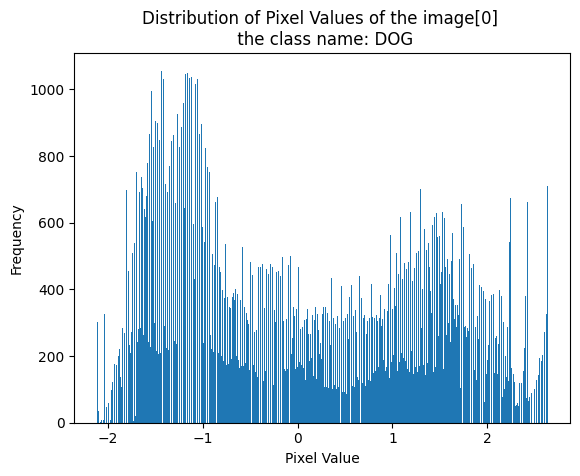

In [18]:
plt.hist(images[0].numpy().flatten() , bins = 500)
plt.title('Distribution of Pixel Values of the image[0] \n the class name: ' + class_names[labels[0]])
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

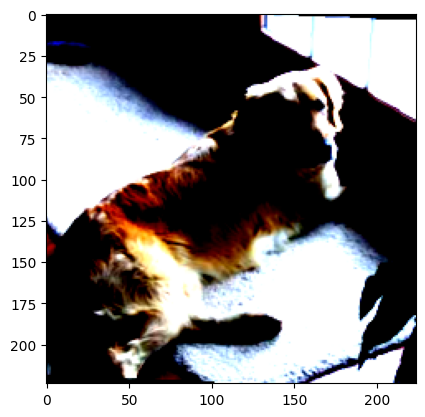

In [19]:
plt.imshow(images[0].numpy().transpose(1,2,0))
plt.show()

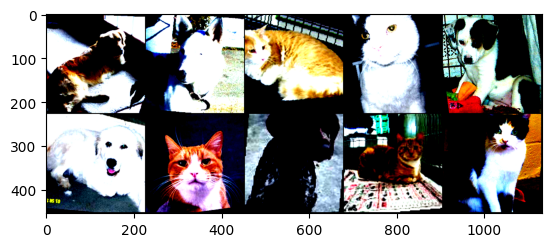

In [20]:
plt.imshow(make_grid(images , nrow = 5).numpy().transpose(1,2,0))
plt.show()

It is obviously clear the the result is the concequence of all the transformations that we applied of the images. So we need to consider the inverse process as follows:

Let's pull all together:

Label: [1 0 0 1 0 1 1 0 0 0]
Class: DOG CAT CAT DOG CAT DOG DOG CAT CAT CAT


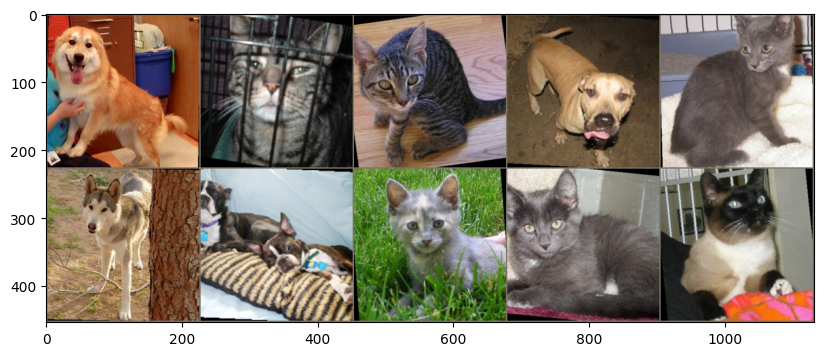

In [21]:
# Grab the first batch of 10 images
for images,labels in train_loader: 
    break

# Print the labels
print('Label:', labels.numpy())
print('Class:', *np.array([class_names[i] for i in labels]))
im = make_grid(images, nrow=5) # the default nrow is 8

# Inverse normalize the images
inv_normalize = transforms.Normalize(
    mean = [-0.485/0.229 , -0.456/0.224 , -0.406/0.225] ,
    std = [1/0.229 , 1/0.224 , 1/0.225]
)

im_inv = inv_normalize(im)

# Print the images
plt.figure(figsize=(12,4))
plt.imshow(np.transpose(im_inv.numpy() , (1, 2, 0)))
plt.show()

## Define the model
We'll start by using a model similar to the one we applied to the CIFAR-10 dataset, except that here we have a binary classification (2 output channels, not 10). Also, we'll add another set of convolution/pooling layers.

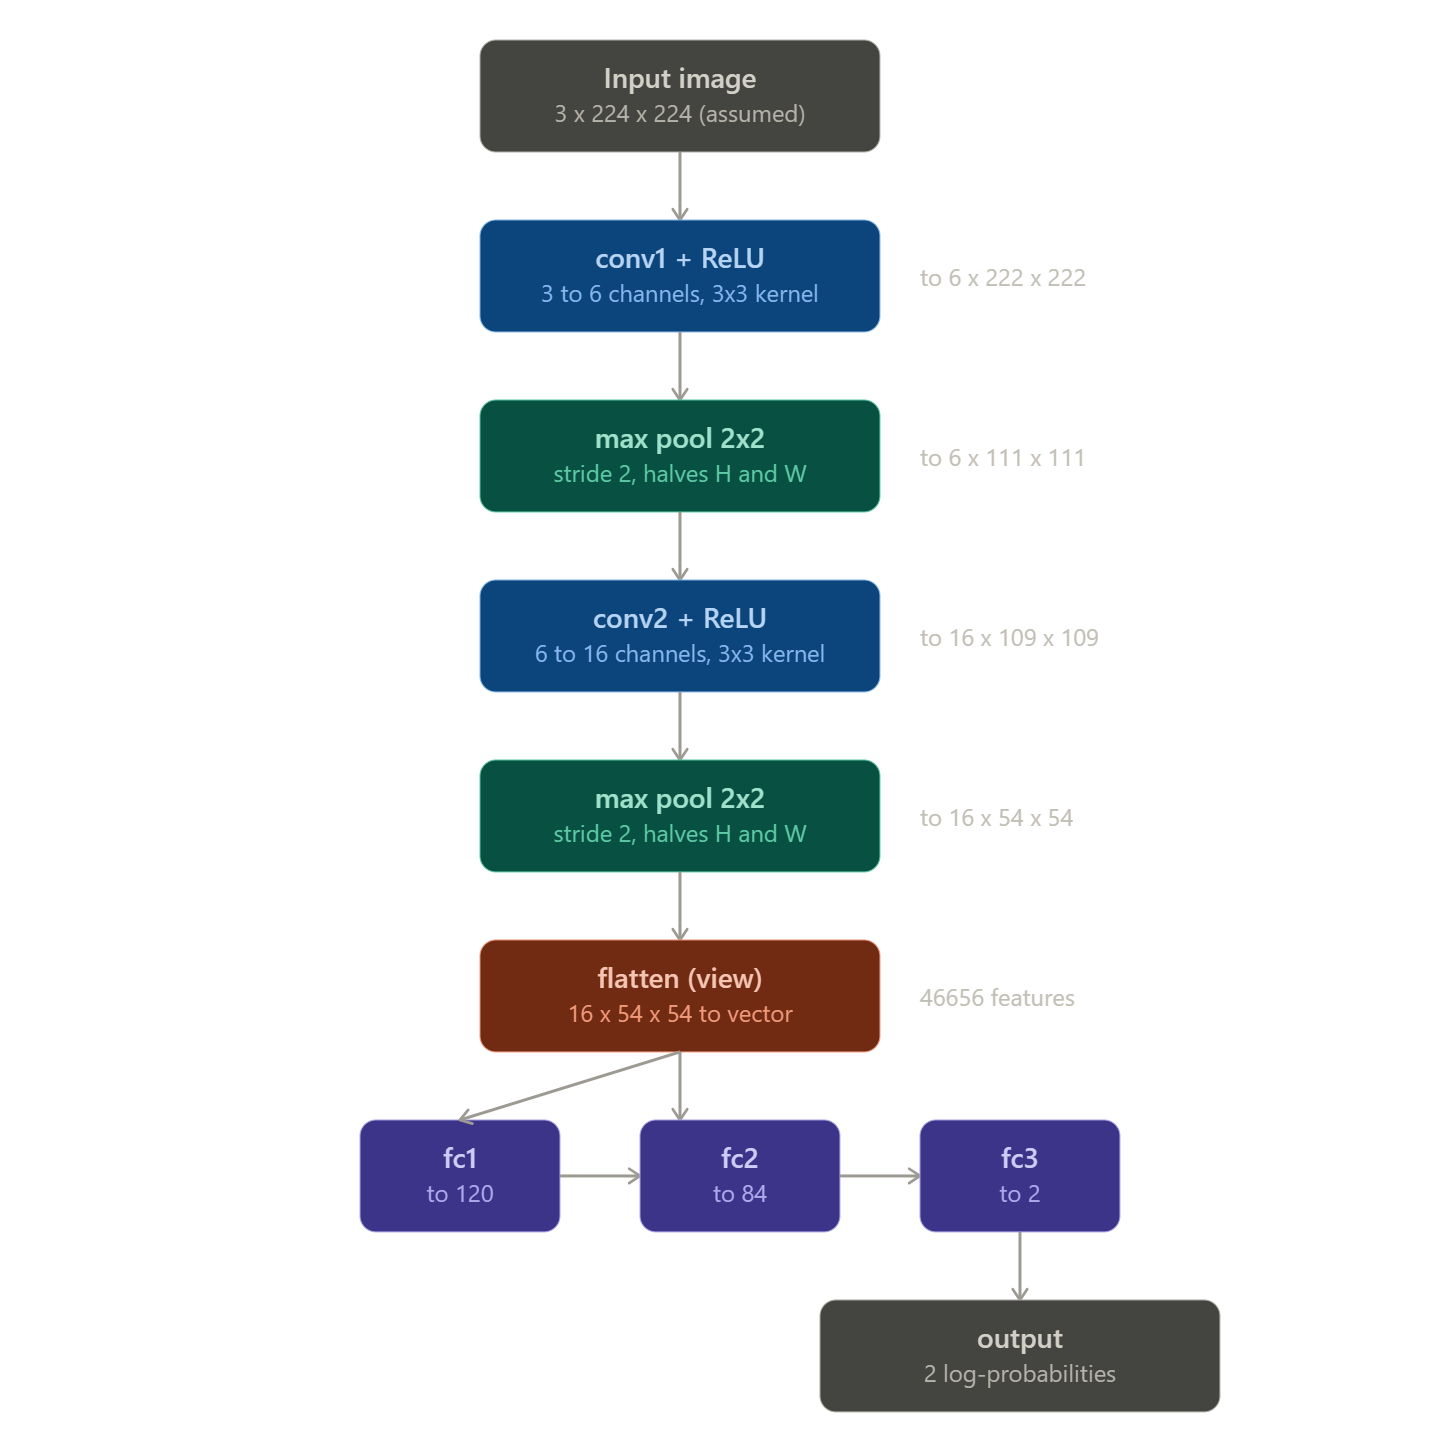

In [22]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels = 3 , out_channels = 6 , kernel_size = 3 , stride = 1)
        self.conv2 = nn.Conv2d(in_channels = 6, out_channels = 16 , kernel_size = 3 , stride = 1)
        # Fully connected layers
        self.fc1 = nn.Linear(in_features = 54*54*16 , out_features = 120)
        self.fc2 = nn.Linear(in_features = 120 , out_features = 84)
        self.fc3 = nn.Linear( in_features = 84 , out_features = 2)

    def forward(self, X):
        X = F.relu(input = self.conv1(X))
        X = F.max_pool2d(input = X , kernel_size = 2 , stride = 2)
        X = F.relu(input = self.conv2(X))
        X = F.max_pool2d(input = X , kernel_size = 2 , stride = 2)
        X = X.view(-1, 54*54*16)
        # Now we can feed X into the fully connected layers
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X, dim=1)

<div class="alert alert-info"><strong>Why <tt>(54x54x16)</tt>?</strong><br>
With 224 pixels per side, the kernels and pooling layers result in $\;(((224-2)/2)-2)/2 = 54.5\;$ which rounds down to 54 pixels per side.</div>

In [23]:
(((224-2)/2)-2)/2

54.5


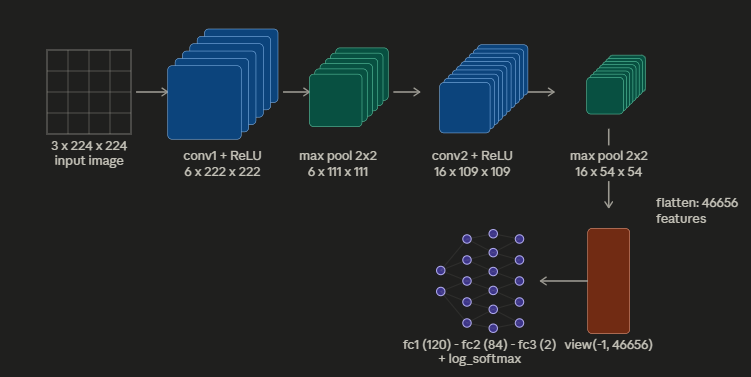


### Instantiate the model, define loss and optimization functions
We're going to call our model "CNNmodel" to differentiate it from an "AlexNetmodel" we'll use later.

In [24]:
torch.manual_seed(101)
CNNmodel = ConvolutionalNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = CNNmodel.parameters(), lr=0.001)
CNNmodel

ConvolutionalNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=46656, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
)

### Looking at the trainable parameters

In [25]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>9,}')
    print(f'_________\n{sum(params):>9,}')

In [26]:
count_parameters(CNNmodel)

      162
        6
      864
       16
5,598,720
      120
   10,080
       84
      168
        2
_________
5,610,222


## Train the model
In the interests of time, we'll limit the number of training batches to 800, and the number of testing batches to 300. We'll train the model on 8000 of 18743 available images, and test it on 3000 out of 6251 images.

In [ ]:
import time
start_time = time.time()

epochs = 2

max_trn_batch = 800
max_tst_batch = 300

train_losses = []
train_correct = []

test_losses = []
test_correct = []

for epoch in range(epochs):
    trn_corr = 0
    tst_corr = 0
    
    # Run the training batches
    for batch_train , (X_train, y_train) in enumerate(train_loader):
        # bathch_train is the batch number
        # X_train is the images
        # y_train is the labels : 0 or 1

        # Transfer the data to the GPU
        X_train, y_train = X_train.to(device), y_train.to(device)
        
        # Limit the number of batches
        if batch_train == max_trn_batch:
            break
        batch_train += 1
        
        # Apply the model
        CNNmodel = CNNmodel.to(device)
        y_pred = CNNmodel(X_train) # y_pred is the predicted labels : 0 or 1
        loss_train = criterion(y_pred, y_train)
 
        # Tally the number of correct predictions
        train_predicted = torch.max(y_pred.data , dim = 1)[1]
        train_batch_corr = (train_predicted == y_train).sum()
        trn_corr += train_batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        # Print interim results
        if batch_train%200 == 0:
            print(f'epoch: {epoch:2}  batch: {batch_train:4} [{10*batch_train:6}/(8000)]  loss: {loss_train.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*batch_train):7.3f}%')

    train_losses.append(loss_train)
    train_correct.append(trn_corr)

    # Run the testing batches
    with torch.no_grad():
        for batch_test , (X_test, y_test) in enumerate(test_loader):
            # Limit the number of batches
            if batch_test == max_tst_batch:
                break

            # Transfer the data to the GPU:
            X_test , y_test = X_test.to(device) , y_test.to(device)

            # Apply the model
            y_val = CNNmodel(X_test)
            loss_test = criterion(y_val , y_test)

            # Tally the number of correct predictions
            test_predicted = torch.max(y_val.data, dim = 1)[1] 
            tst_corr += (test_predicted == y_test).sum()


        test_losses.append(loss_test)
        test_correct.append(tst_corr)

end_time = time.time()

print(f'\nDuration: {(end_time - start_time)/60:.0f} minutes & {(end_time - start_time)%60:.0f} seconds.') # print the time elapsed

epoch:  0  batch:  200 [  2000/(8000)]  loss: 0.64654434  accuracy:  54.300%
epoch:  0  batch:  400 [  4000/(8000)]  loss: 0.65997368  accuracy:  56.775%
epoch:  0  batch:  600 [  6000/(8000)]  loss: 0.72498685  accuracy:  60.300%
epoch:  0  batch:  800 [  8000/(8000)]  loss: 0.49330801  accuracy:  61.638%
epoch:  1  batch:  200 [  2000/(8000)]  loss: 0.42830357  accuracy:  70.700%
epoch:  1  batch:  400 [  4000/(8000)]  loss: 0.60919905  accuracy:  71.625%
epoch:  1  batch:  600 [  6000/(8000)]  loss: 0.45220155  accuracy:  71.383%
epoch:  1  batch:  800 [  8000/(8000)]  loss: 0.64604694  accuracy:  71.312%

Duration: 97 minutes & 28 seconds.


## Save the trained model

In [30]:
torch.save(CNNmodel.state_dict(), 'CustomImageCNNModel.pt')

## Evaluate model performance

In [42]:
[i.item() for i in train_losses]

[0.49330800771713257, 0.6460469365119934]

In [43]:
[i.item() for i in test_losses]

[0.6593223810195923,
 0.7249642610549927,
 0.6277572512626648,
 0.873131275177002,
 0.7401849031448364,
 0.6761271357536316,
 0.6692101955413818,
 0.5910068154335022,
 0.7208665609359741,
 0.8080590963363647,
 0.6840468645095825,
 0.7110899686813354,
 0.7442532777786255,
 0.6865606307983398,
 0.9090214967727661,
 0.6223723292350769,
 0.8023056983947754,
 0.6909193396568298,
 0.7488938570022583,
 0.5745366811752319,
 0.765472412109375,
 0.6082509160041809,
 0.7991681694984436,
 0.6808257102966309,
 0.6813300251960754,
 0.7218558192253113,
 0.6982600092887878,
 0.7268732786178589,
 0.7453181147575378,
 0.6930996775627136,
 0.6738585829734802,
 0.5573660731315613,
 0.6844950914382935,
 0.7318433523178101,
 0.6703842878341675,
 0.7994817495346069,
 0.6810291409492493,
 0.6235691905021667,
 0.7263053059577942,
 0.6664563417434692,
 0.5238393545150757,
 0.6206437349319458,
 0.7287846803665161,
 0.6364163160324097,
 0.7682633399963379,
 0.6080327033996582,
 0.6675237417221069,
 0.759794771671

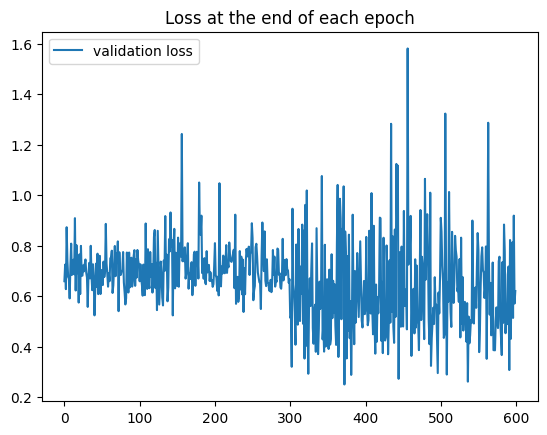

In [45]:
#plt.plot([i.item() for i in train_losses], label='training loss')
plt.plot([i.item() for i in test_losses], label='validation loss')
plt.title('Loss at the end of each epoch')
plt.legend()
plt.show()

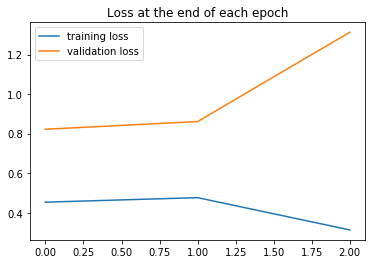

In [12]:
plt.plot(train_losses, label='training loss')
plt.plot(test_losses, label='validation loss')
plt.title('Loss at the end of each epoch')
plt.legend()
plt.show()

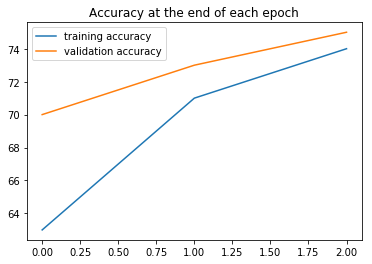

In [13]:
plt.plot([t/80 for t in train_correct], label='training accuracy')
plt.plot([t/30 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend()
plt.show()


In [14]:
print(test_correct)
print(f'Test accuracy: {test_correct[-1].item()*100/3000:.3f}%')

[tensor(2109), tensor(2195), tensor(2254)]
Test accuracy: 75.133%


## Download a pretrained model
Torchvision has a number of proven models available through <a href='https://pytorch.org/docs/stable/torchvision/models.html#classification'><tt><strong>torchvision.models</strong></tt></a>:
<ul>
<li><a href="https://arxiv.org/abs/1404.5997">AlexNet</a></li>
<li><a href="https://arxiv.org/abs/1409.1556">VGG</a></li>
<li><a href="https://arxiv.org/abs/1512.03385">ResNet</a></li>
<li><a href="https://arxiv.org/abs/1602.07360">SqueezeNet</a></li>
<li><a href="https://arxiv.org/abs/1608.06993">DenseNet</a></li>
<li><a href="https://arxiv.org/abs/1512.00567">Inception</a></li>
<li><a href="https://arxiv.org/abs/1409.4842">GoogLeNet</a></li>
<li><a href="https://arxiv.org/abs/1807.11164">ShuffleNet</a></li>
<li><a href="https://arxiv.org/abs/1801.04381">MobileNet</a></li>
<li><a href="https://arxiv.org/abs/1611.05431">ResNeXt</a></li>
</ul>
These have all been trained on the <a href='http://www.image-net.org/'>ImageNet</a> database of images. Our only task is to reduce the output of the fully connected layers from (typically) 1000 categories to just 2.

To access the models, you can construct a model with random weights by calling its constructor:<br>
<pre>resnet18 = models.resnet18()</pre>
You can also obtain a pre-trained model by passing pretrained=True:<br>
<pre>resnet18 = models.resnet18(pretrained=True)</pre>
All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

Feel free to investigate the different models available. Each one will be downloaded to a cache directory the first time they're accessed - from then on they'll be available locally.

For its simplicity and effectiveness, we'll use AlexNet:

In [15]:
AlexNetmodel = models.alexnet(pretrained=True)
AlexNetmodel

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU(inplace)
    (3): Dropout(p

<div class="alert alert-info">This model uses <a href='https://pytorch.org/docs/master/nn.html#torch.nn.AdaptiveAvgPool2d'><tt><strong>torch.nn.AdaptiveAvgPool2d(<em>output_size</em>)</strong></tt></a> to convert the large matrix coming out of the convolutional layers to a (6x6)x256 matrix being fed into the fully connected layers.</div>

## Freeze feature parameters
We want to freeze the pre-trained weights & biases. We set <tt>.requires_grad</tt> to False so we don't backprop through them.

In [17]:
for param in AlexNetmodel.parameters():
    param.requires_grad = False

## Modify the classifier
Next we need to modify the fully connected layers to produce a binary output. The section is labeled "classifier" in the AlexNet model.<br>
Note that when we assign new layers, their parameters default to <tt>.requires_grad=True</tt>.

In [18]:
torch.manual_seed(42)
AlexNetmodel.classifier = nn.Sequential(nn.Linear(9216, 1024),
                                 nn.ReLU(),
                                 nn.Dropout(0.4),
                                 nn.Linear(1024, 2),
                                 nn.LogSoftmax(dim=1))
AlexNetmodel

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Linear(in_features=9216, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4)
    (3): Linear(in_featur

In [19]:
# These are the TRAINABLE parameters:
count_parameters(AlexNetmodel)

 9437184
    1024
    2048
       2
________
 9440258


## Define loss function & optimizer
We only want to optimize the classifier parameters, as the feature parameters are frozen.

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(AlexNetmodel.classifier.parameters(), lr=0.001)

## Train the model
Remember, we're only training the fully connected layers. The convolutional layers have fixed weights and biases. For this reason, we only need to run one epoch.

In [22]:
import time
start_time = time.time()

epochs = 1

max_trn_batch = 800
max_tst_batch = 300

train_losses = []
train_correct = []

test_losses = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    
    # Run the training batches
    for batch_train, (X_train, y_train) in enumerate(train_loader):
        if batch_train == max_trn_batch:
            break
        batch_train+=1

        # Transfer the data to the GPU
        X_train, y_train = X_train.to(device), y_train.to(device)
        
        # Apply the model
        AlexNetmodel = AlexNetmodel.to(device)
        y_pred = AlexNetmodel(X_train)
        loss_train = criterion(y_pred, y_train)
 
        # Tally the number of correct predictions
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print interim results
        if b%200 == 0:
            print(f'epoch: {i:2}  batch: {b:4} [{10*b:6}/8000]  loss: {loss.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*b):7.3f}%')

    train_losses.append(loss)
    train_correct.append(trn_corr)

    # Run the testing batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            if b == max_tst_batch:
                break

            # Apply the model
            y_val = AlexNetmodel(X_test)

            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test).sum()

    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)

print(f'\nDuration: {time.time() - start_time:.0f} seconds') # print the time elapsed

epoch:  0  batch:  200 [  2000/8000]  loss: 0.01413172  accuracy:  88.900%
epoch:  0  batch:  400 [  4000/8000]  loss: 0.24275371  accuracy:  90.825%
epoch:  0  batch:  600 [  6000/8000]  loss: 0.09340305  accuracy:  91.900%
epoch:  0  batch:  800 [  8000/8000]  loss: 0.07545806  accuracy:  92.250%

Duration: 513 seconds


In [23]:
print(test_correct)
print(f'Test accuracy: {test_correct[-1].item()*100/3000:.3f}%')

[tensor(2810)]
Test accuracy: 93.667%


## Run a new image through the model
We can also pass a single image through the model to obtain a prediction.<br>
Pick a number from 0 to 6250, assign it to "x", and we'll use that value to select an image from the Cats and Dogs test set.

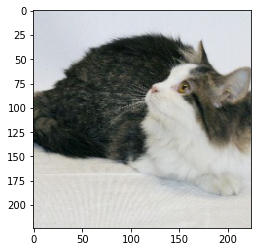

In [31]:
x = 2019
im = inv_normalize(test_data[x][0])
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

In [32]:
test_data[x][0].shape

torch.Size([3, 224, 224])

In [35]:
# CNN Model Prediction:

CNNmodel.eval()
with torch.no_grad():
    new_pred = CNNmodel(test_data[x][0].view(1,3,224,224)).argmax()
print(f'Predicted value: {new_pred.item()} {class_names[new_pred.item()]}')

Predicted value: 1 DOG


In [36]:
# AlexNet Model Prediction:

AlexNetmodel.eval()
with torch.no_grad():
    new_pred = AlexNetmodel(test_data[x][0].view(1,3,224,224)).argmax()
print(f'Predicted value: {new_pred.item()} {class_names[new_pred.item()]}')

Predicted value: 0 CAT


## Great job!